In [1]:
import os
import pandas as pd
import numpy as np 
import seaborn as sns
from tqdm import tqdm
import pickle

from pydub import AudioSegment
from IPython.display import Audio

import librosa
import librosa.display
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, accuracy_score
import itertools

import warnings
warnings.filterwarnings("ignore")

In [2]:
ds_train = pd.read_csv('/Users/camcortes/Documents/birds-sounds/data/chunks_specie_sample_train.csv')
ds_test = pd.read_csv('/Users/camcortes/Documents/birds-sounds/data/chunks_specie_sample_test.csv')
ds_val = pd.read_csv('/Users/camcortes/Documents/birds-sounds/data/chunks_specie_sample_val.csv')
ds_train = ds_train[['audio_path', 'label']]
ds_test = ds_test[['audio_path', 'label']]
ds_val = ds_val[['audio_path', 'label']]
print(ds_train.shape)
print(ds_test.shape)
print(ds_val.shape)
ds_train.sample(5)

(13501, 2)
(2270, 2)
(6157, 2)


,audio_path,label
9219,chunks/188839_chunk75.mp3,Troglodytes aedon
1500,chunks/803634_chunk17.mp3,Catharus fuscescens
11547,chunks/891689_chunk15.mp3,Quiscalus mexicanus
4139,chunks/139061_chunk17.mp3,Icterus spurius
4584,chunks/259122_chunk1.mp3,Piprites chloris


In [3]:
#ds_train = ds_train[ds_train['audio_path'] != 'chunks/337985_chunk40.mp3']
#ds_train.reset_index(drop=True, inplace=True)

# guardar los datasets
#ds_train.to_csv('/Users/camcortes/Documents/birds-sounds/data/chunks_specie_sample_train.csv', index=False)

In [4]:
# label encoder
le = LabelEncoder()
ds_train['label'] = le.fit_transform(ds_train['label'])
ds_test['label'] = le.transform(ds_test['label'])
ds_val['label'] = le.transform(ds_val['label'])

In [5]:
etiquetas = ds_train['label']
clases, conteo_clases = np.unique(etiquetas, return_counts=True)
weight = dict(zip(clases, np.max(conteo_clases) / conteo_clases))

In [6]:
X = ds_train['audio_path']
y = ds_train['label']

X_test = ds_test['audio_path']
y_test = ds_test['label']

X_val = ds_val['audio_path']
y_val = ds_val['label']

In [7]:
num_clases = y.nunique()
print(num_clases)

106


In [8]:
#getting mfcc features for all the data points in test and train

def get_mfcc(path):
    """
    Extracts MFCC (Mel-frequency cepstral coefficients) features from an audio file.
    
    Parameters:
    path (str): The file path to the audio file.
    
    Returns:
    numpy.ndarray: A 2D array where each row corresponds to the MFCC features of a frame.
    """
    y, sr = librosa.load(path, sr=None, mono=True)
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128, fmax=10000)
    mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=40)
    return mfccs.T

In [9]:
def process_audio_files(X, y):
    """
    Processes a list of audio file paths to extract MFCC features and resize them.
    
    Args:
        X (pd.Series): A pandas Series containing paths to audio files.
        y (pd.Series): A pandas Series containing labels corresponding to the audio files.
        
    Returns:
        tuple: A tuple containing:
            - X_processed (np.ndarray): A numpy array of processed MFCC features with shape (num_files, 65, 40).
            - y_processed (np.ndarray): A numpy array of labels corresponding to the audio files.
    """
    temp = []
    label = []
    
    for i in tqdm(range(len(X))):
        audio_path = X.iloc[i]
        mfcc = get_mfcc(audio_path)
        mfcc = np.resize(mfcc, (65, 40,))
        temp.append(mfcc)
        label.append(y.iloc[i])
        
    X_processed = np.asarray(temp)
    y_processed = np.asarray(label)
    
    return X_processed, y_processed

In [10]:
#%%time
X_processed, y = process_audio_files(X, y)
X_test_processed, y_test = process_audio_files(X_test, y_test)
X_val_processed, y_val = process_audio_files(X_val, y_val)

100%|██████████| 6157/6157 [00:48<00:00, 127.02it/s]


In [11]:
print(f'El conjunto de entrenamiento tiene la forma {X_processed.shape}')
print(f'Los labels del conjunto de entrenamiento tiene la forma {y.shape}')

El conjunto de entrenamiento tiene la forma (13501, 65, 40)
Los labels del conjunto de entrenamiento tiene la forma (13501,)


## **Modelo**

In [12]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
import keras.backend as K

tf.keras.backend.clear_session()

In [13]:
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

Num GPUs Available:  1


In [14]:
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [15]:
# Add attention layer to the deep learning network
class Attention(layers.Layer):
    """
    Custom Keras Layer implementing an Attention mechanism.
    
    Methods
    -------
    build(input_shape)
        Initializes the weights and biases for the attention mechanism.
    
    call(x)
        Applies the attention mechanism to the input tensor `x` and returns the context vector.
        
    Parameters
    ----------
    input_shape : tuple
        Shape of the input tensor.
        
    x : tensor
        Input tensor to which the attention mechanism is applied.
        
    Returns
    -------
    tensor
        Context vector obtained after applying the attention mechanism.
    """
    def __init__(self, **kwargs):
        super(Attention, self).__init__(**kwargs)
        
    def build(self, input_shape):
        self.W = self.add_weight(name='attention_weight', shape=(input_shape[-1], 1), 
                                 initializer='random_normal', trainable=True)
        self.b = self.add_weight(name='attention_bias', shape=(input_shape[1], 1), 
                                 initializer='zeros', trainable=True)
        super(Attention, self).build(input_shape)
        
    def call(self, x):
        # Alignment scores. Pass them through tanh function
        e = tf.tanh(tf.matmul(x, self.W) + self.b)  # Cambiado K.dot por tf.matmul
        # Remove dimension of size 1
        e = tf.squeeze(e, axis=-1)  # Cambiado K.squeeze por tf.squeeze
        # Compute the weights
        alpha = tf.nn.softmax(e)  # Cambiado K.softmax por tf.nn.softmax
        # Reshape to tensorFlow format
        alpha = tf.expand_dims(alpha, axis=-1)  # Cambiado K.expand_dims por tf.expand_dims
        # Compute the context vector
        context = x * alpha
        context = tf.reduce_sum(context, axis=1)  # Cambiado K.sum por tf.reduce_sum
        return context

In [16]:
#Create model

#input
input = layers.Input(shape=(65,40), name='input_layer')

#cnn
x = layers.Conv1D(256, (3,), activation='relu')(input)
x = layers.BatchNormalization()(x)
x = layers.Conv1D(128, (3,), activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Conv1D(64, (3,), activation='relu')(x)
x = layers.BatchNormalization()(x)
#lstm
x = layers.LSTM(256, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
x = layers.LSTM(128, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
x = layers.LSTM(64, return_sequences = True)(x)
x = layers.Dropout(0.5)(x)
x = Attention()(x)
#dense
x = layers.Dense(256,'relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(128,'relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64,'relu')(x)
x = layers.Dropout(0.5)(x)

#output
output = layers.Dense(num_clases, activation='softmax', name='output_layer')(x)

model = Model(inputs=input, outputs=output)
model.summary()

2024-11-26 23:47:02.321509: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2024-11-26 23:47:02.321536: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2024-11-26 23:47:02.321543: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2024-11-26 23:47:02.321582: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2024-11-26 23:47:02.321595: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 65, 40)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 63, 256)        │        30,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 63, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 61, 128)        │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 59, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 59, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 59, 256)        │       328,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 59, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 59, 128)        │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 59, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 59, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ attention (Attention)           │ (None, 64)             │           123 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 106)            │         6,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 795,877 (3.04 MB)

 Trainable params: 794,981 (3.03 MB)

 Non-trainable params: 896 (3.50 KB)

In [17]:
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    'model_weights_mfcc.keras',  
    monitor='val_loss',
    mode='min',
    verbose=1,
    save_weights_only=False,  # guardar solo los pesos
    save_best_only=True,     # guardar solo el mejor modelo
)

# Callback para TensorBoard
tensorboard_cb = tf.keras.callbacks.TensorBoard(
    log_dir='logs',
    histogram_freq=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.1, 
    patience=15, 
    min_lr=0.00001)

# Callback para EarlyStopping
early_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    mode='min'
)

callbacks = [checkpoint_cb, tensorboard_cb, early_callback, reduce_lr]

In [18]:
#model.load_weights('model_weights_mfcc-v3.weights.h5')

# Paso 3: Compilar el modelo (opcional)
#model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [19]:
#compile
ls = tf.keras.losses.SparseCategoricalCrossentropy()
adam = tf.keras.optimizers.Adam(learning_rate=0.01)
model.compile(adam, ls, metrics=['accuracy'])

history = model.fit(X_processed, y, 
                    validation_data=(X_val_processed, y_val),
                    callbacks=callbacks,
                    epochs=1000,
                    batch_size=32,
                    class_weight=weight)

Epoch 1/1000


2024-11-26 23:47:06.438129: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


 40/422 ━━━━━━━━━━━━━━━━━━━━ 59s 156ms/step - accuracy: 0.0048 - loss: 19.3710

KeyboardInterrupt: 

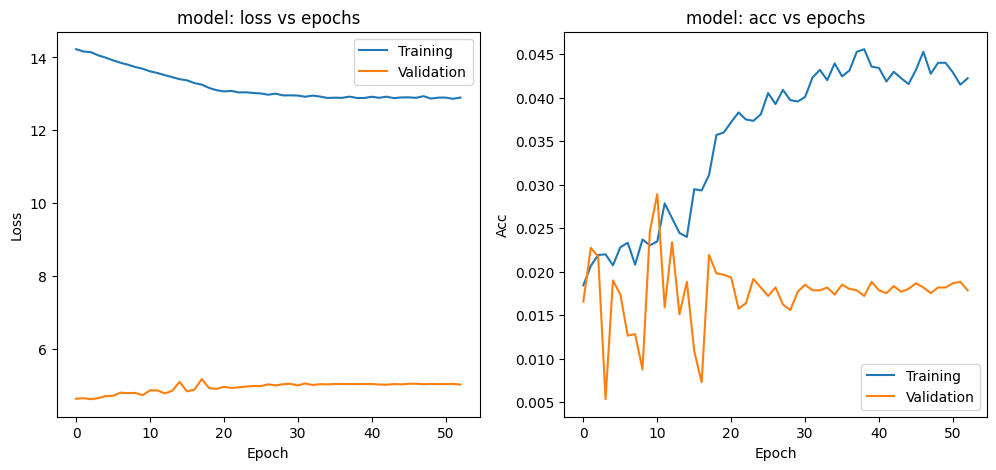

In [51]:
fig = plt.figure(figsize=(12, 5))
fig.add_subplot(121)

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model: loss vs epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='upper right')

fig.add_subplot(122)

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model: acc vs epochs')
plt.ylabel('Acc')
plt.xlabel('Epoch')
plt.legend(['Training', 'Validation'], loc='lower right')
plt.show()

## **Predicción**

In [52]:
#carga el modelo model_weights_mfcc
model = tf.keras.models.load_model('model_weights_mfcc.keras', custom_objects={'Attention': Attention})

In [53]:
preds = model.predict(X_test_processed)
model.evaluate(X_test_processed, y_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0060 - loss: 4.8249


[4.779743194580078, 0.006607929710298777]

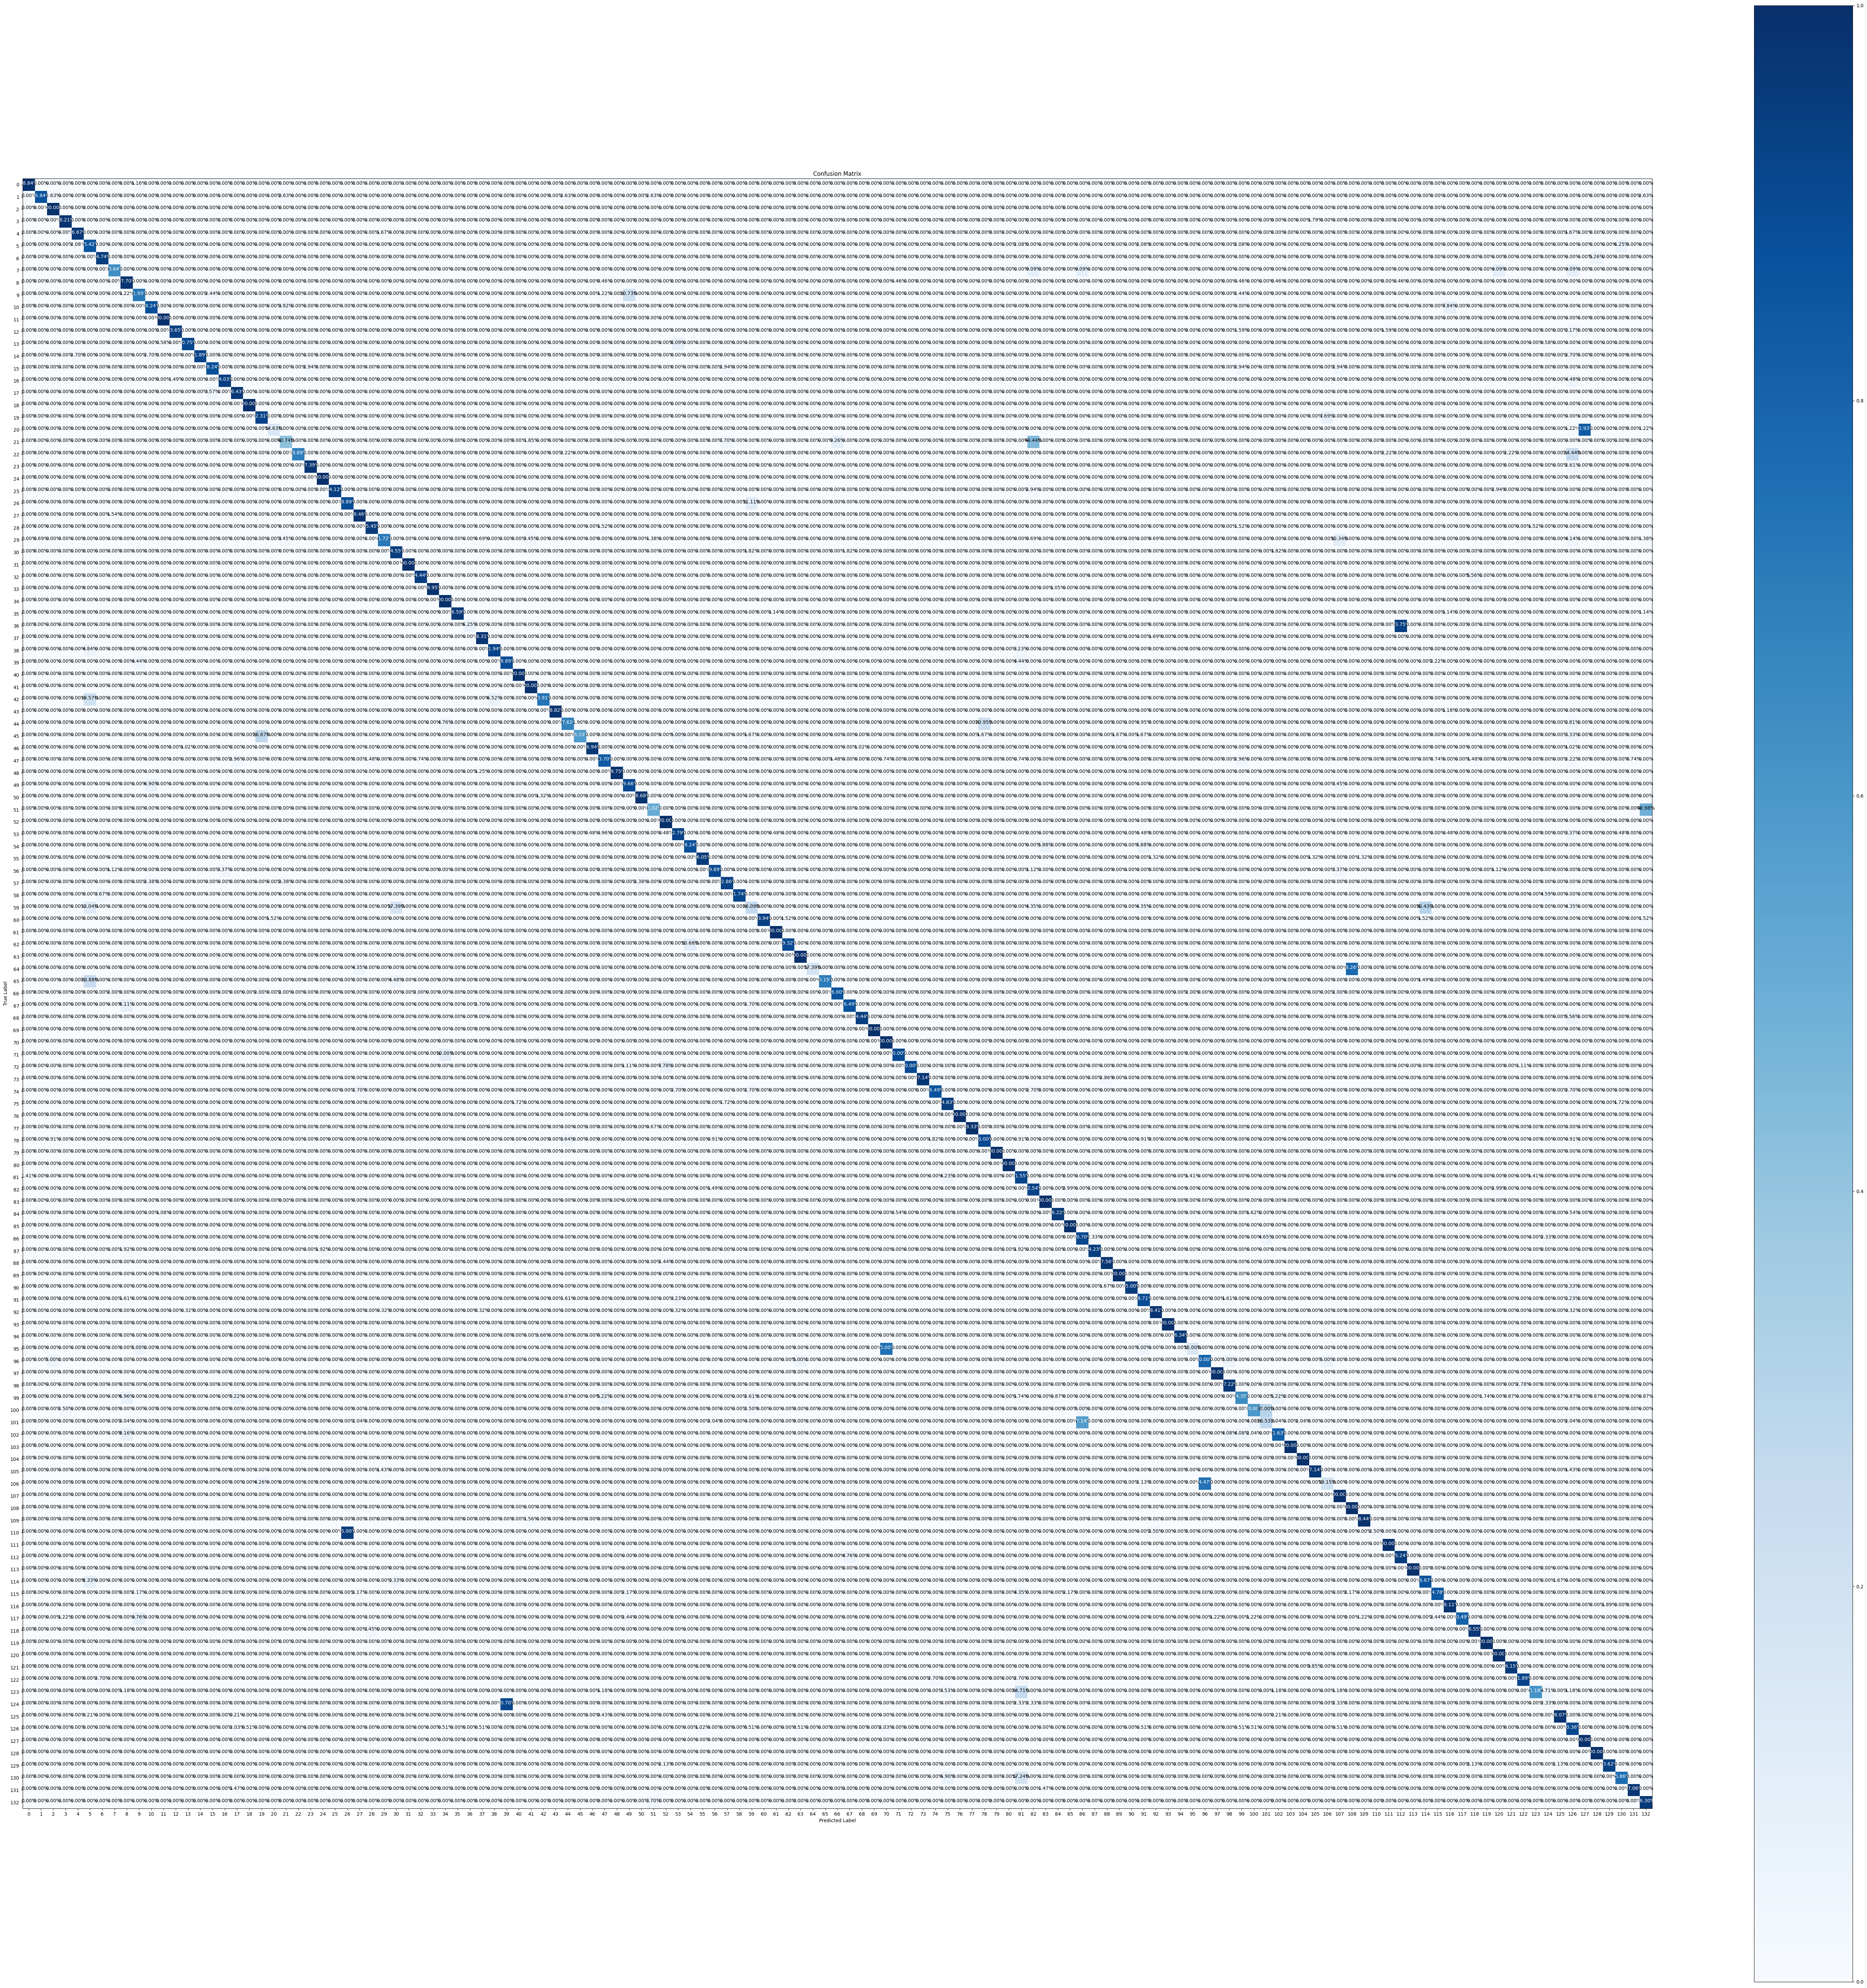

In [ ]:
cm = confusion_matrix(y_test, np.argmax(preds, axis=1))

# Número de clases
num_classes = cm.shape[0]

# Normalizar la matriz de confusión
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Graficar
plt.figure(figsize=(60, 58))  # Opcional, para ajustar el tamaño de la figura
plt.imshow(cm_normalized, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, range(num_classes), rotation=0)
plt.yticks(tick_marks, range(num_classes))

# Anotar la matriz
for i, j in itertools.product(range(cm_normalized.shape[0]), range(cm_normalized.shape[1])):
    plt.text(j, i, f"{cm_normalized[i, j]:.2%}",
             horizontalalignment="center",
             color="white" if cm_normalized[i, j] > 0.5 else "black")

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

# Guardar la figura en formato PDF
plt.savefig('confusion_matrix.pdf', format='pdf')
plt.show()

In [54]:
accuracy_score(y_test, np.argmax(preds, axis=1))

0.006607929515418502

In [55]:
#codificar las etiquetas
y_test_labels = le.inverse_transform(y_test)
y_pred_labels = le.inverse_transform(np.argmax(preds, axis=1))

In [56]:
print(classification_report(y_test_labels, y_pred_labels))

                                 precision    recall  f1-score   support

               Anthus rubescens       0.00      0.00      0.00        21
           Arremon brunneinucha       0.00      0.00      0.00        12
             Arremon taciturnus       0.00      0.00      0.00        27
         Arremonops conirostris       0.00      0.00      0.00        63
                   Cacicus cela       0.00      0.00      0.00        26
            Cacicus haemorrhous       0.00      0.00      0.00         8
          Camptostoma obsoletum       0.00      0.00      0.00        12
Campylorhamphus trochilirostris       0.00      0.00      0.00         6
     Cantorchilus nigricapillus       0.00      0.00      0.00        12
       Cercomacroides tyrannina       0.00      0.00      0.00        20
         Certhiaxis cinnamomeus       0.00      0.00      0.00        10
           Chamaeza campanisona       0.00      0.00      0.00         7
      Chlorospingus flavopectus       0.00      0.